In [5]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [13]:
df.shape

(10000, 3)

In [4]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_6576\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

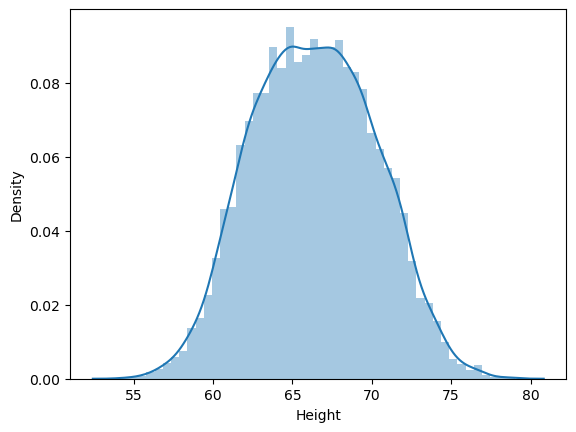

In [6]:
sns.distplot(df['Height'])

<Axes: xlabel='Height'>

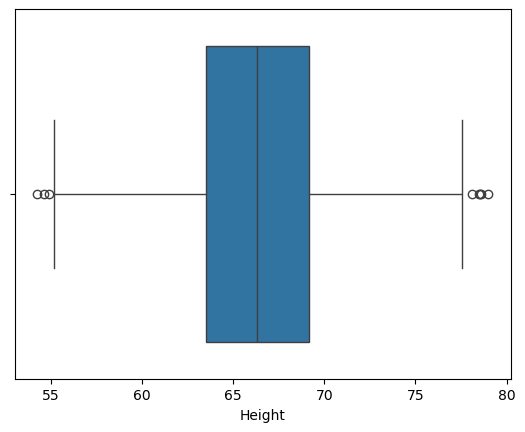

In [8]:
sns.boxplot(x=df['Height'])

In [9]:
upperlimit = df['Height'].quantile(0.99)
lowerlimit = df['Height'].quantile(0.1)

In [10]:
upperlimit, lowerlimit

(74.7857900583366, 61.41270131336016)

In [12]:
# Find Outliers

df[(df['Height'] > upperlimit) | (df['Height'] < lowerlimit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9984,Female,59.047029,111.707369
9988,Female,59.538729,121.244876
9989,Female,60.955084,95.686674
9993,Female,60.030434,97.687432


In [14]:
# Trimming

new_df = df[(df['Height'] < upperlimit) & (df['Height'] > lowerlimit)]

In [15]:
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: xlabel='Height'>

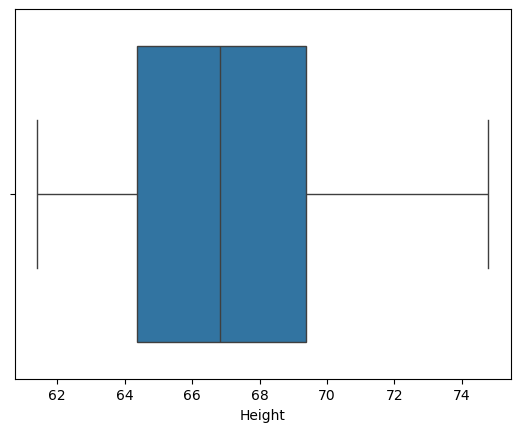

In [18]:
sns.boxplot(x=new_df['Height'])

In [19]:
# Capping --> Winsorization

df['Height'] = np.where(df['Height'] > upperlimit, upperlimit,
                       np.where(df['Height'] < lowerlimit, lowerlimit, df['Height']))

In [20]:
df.shape

(10000, 3)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_6576\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

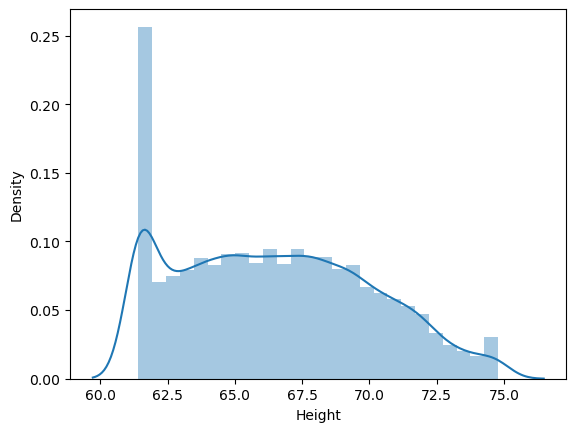

In [21]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

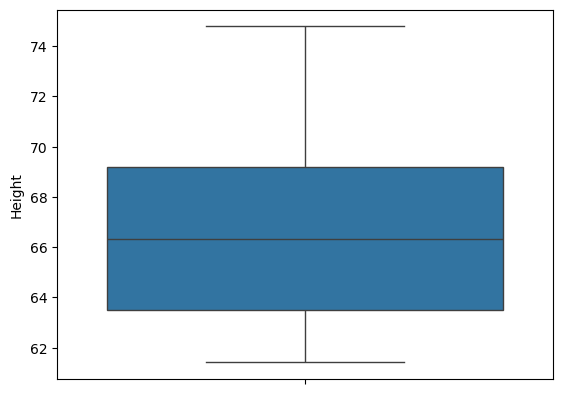

In [22]:
sns.boxplot(df['Height'])